# Niveau 2 - Tâche 2 : Arbre de Décision pour la Classification

**Dataset choisi : Iris**

Reprend l'exemple donné dans la consigne (prédiction de l'espèce de fleur).

**Objectifs couverts :**
1. Entraînement d'un arbre de décision
2. Visualisation de la structure de l'arbre
3. Élagage (pruning) pour éviter le sur-apprentissage
4. Évaluation (accuracy, F1-score)

**Outils :** Python, scikit-learn, pandas, matplotlib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report

df = pd.read_csv('data/iris.csv')
le = LabelEncoder()
X = df.drop(columns=['species'])
y = le.fit_transform(df['species'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (120, 4)  Test: (30, 4)


## 1. Arbre de décision sans contrainte (référence)

In [2]:
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

pred_train_full = tree_full.predict(X_train)
pred_test_full = tree_full.predict(X_test)

print(f"Accuracy train (arbre complet): {accuracy_score(y_train, pred_train_full):.3f}")
print(f"Accuracy test  (arbre complet): {accuracy_score(y_test, pred_test_full):.3f}")
print(f"Profondeur de l'arbre: {tree_full.get_depth()}, nb feuilles: {tree_full.get_n_leaves()}")


Accuracy train (arbre complet): 1.000
Accuracy test  (arbre complet): 0.933
Profondeur de l'arbre: 5, nb feuilles: 8


## 2. Visualisation de la structure de l'arbre

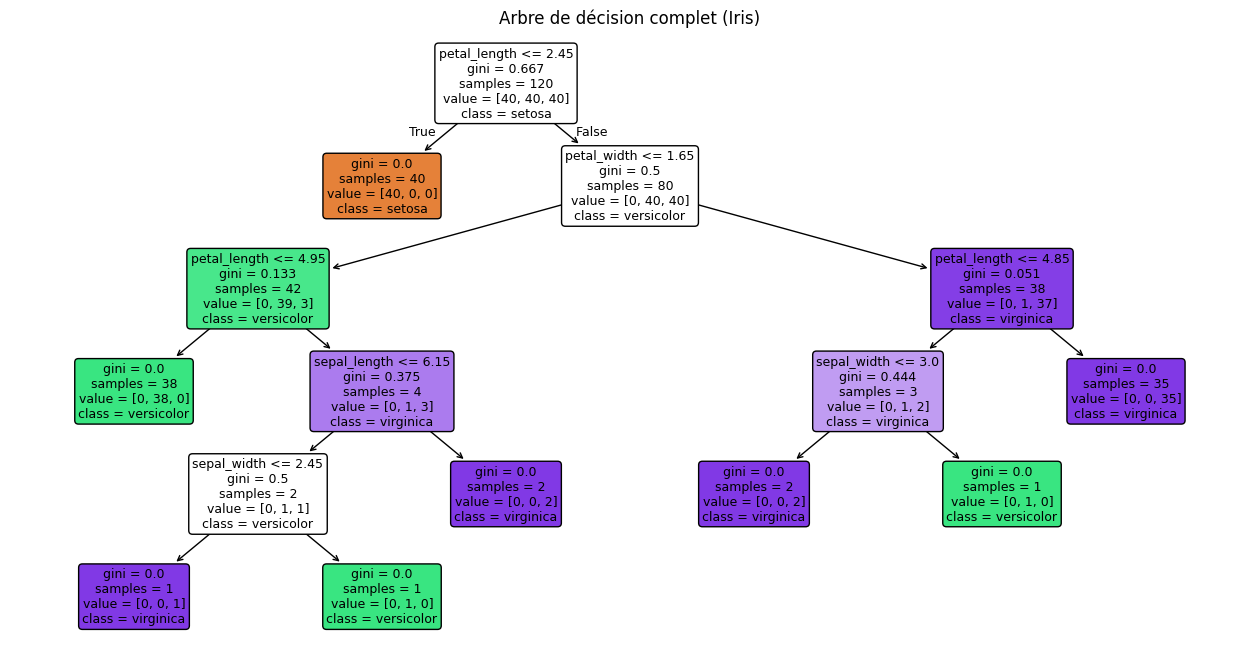

In [3]:
plt.figure(figsize=(16, 8))
plot_tree(tree_full, feature_names=X.columns, class_names=le.classes_, filled=True, rounded=True, fontsize=9)
plt.title("Arbre de décision complet (Iris)")
plt.show()


## 3. Élagage (pruning) pour éviter le sur-apprentissage

On compare plusieurs profondeurs maximales pour trouver un compromis biais/variance, puis on utilise le cost-complexity pruning (`ccp_alpha`).

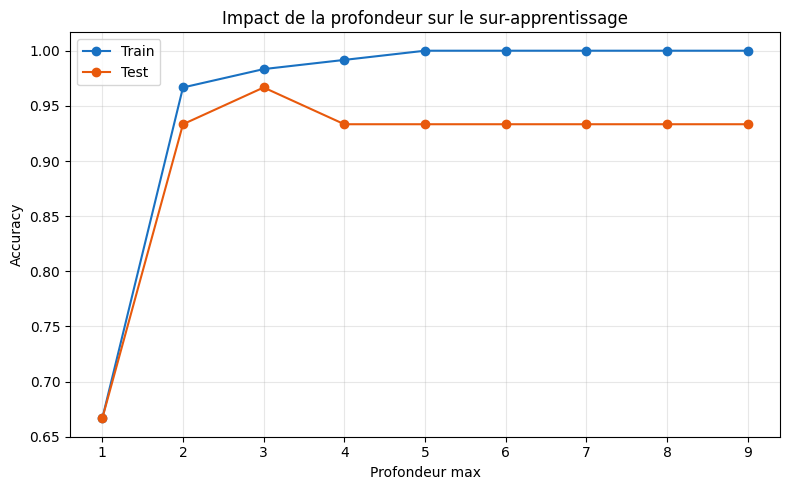

In [4]:
depths = range(1, 10)
train_scores, test_scores = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, t.predict(X_train)))
    test_scores.append(accuracy_score(y_test, t.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(list(depths), train_scores, marker='o', label='Train', color='#1971c2')
plt.plot(list(depths), test_scores, marker='o', label='Test', color='#e8590c')
plt.xlabel('Profondeur max'); plt.ylabel('Accuracy')
plt.title("Impact de la profondeur sur le sur-apprentissage")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
# Cost-complexity pruning
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

test_accs = []
trees = []
for alpha in ccp_alphas:
    t = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    t.fit(X_train, y_train)
    trees.append(t)
    test_accs.append(accuracy_score(y_test, t.predict(X_test)))

best_idx = int(np.argmax(test_accs))
best_alpha = ccp_alphas[best_idx]
tree_pruned = trees[best_idx]

print(f"Meilleur ccp_alpha: {best_alpha:.5f}")
print(f"Accuracy test (arbre élagué): {test_accs[best_idx]:.3f}")
print(f"Profondeur après élagage: {tree_pruned.get_depth()}, nb feuilles: {tree_pruned.get_n_leaves()}")


Meilleur ccp_alpha: 0.00625
Accuracy test (arbre élagué): 0.967
Profondeur après élagage: 4, nb feuilles: 6


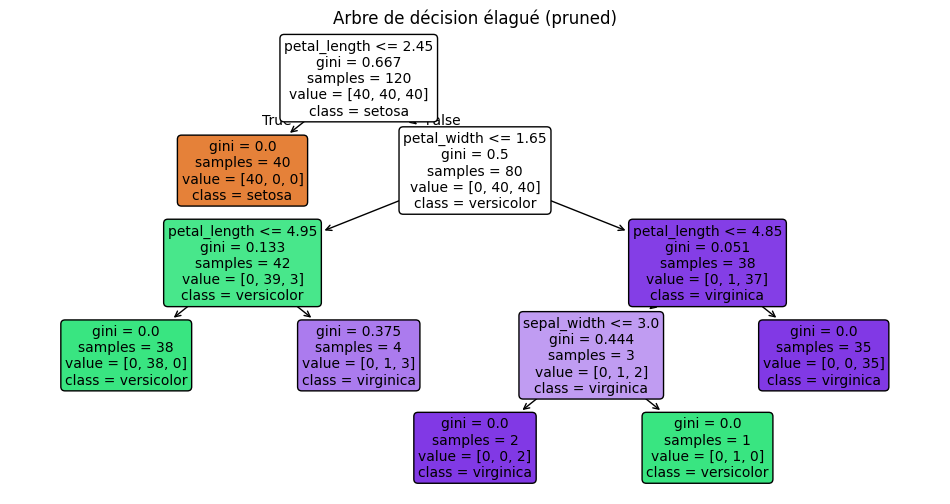

In [6]:
plt.figure(figsize=(12, 6))
plot_tree(tree_pruned, feature_names=X.columns, class_names=le.classes_, filled=True, rounded=True, fontsize=10)
plt.title("Arbre de décision élagué (pruned)")
plt.show()


## 4. Évaluation finale du modèle élagué

In [7]:
y_pred = tree_pruned.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {acc:.3f}")
print(f"F1-score (macro): {f1:.3f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.967
F1-score (macro): 0.967

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Conclusion

L'arbre complet atteint déjà une bonne accuracy sur Iris (dataset simple), mais l'élagage permet d'obtenir un arbre nettement plus petit (moins de feuilles, profondeur réduite) sans perte de performance sur le test set — un bon compromis interprétabilité/généralisation.
